In [101]:
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix

In [103]:
df=pd.read_csv('Titanic-Dataset.csv')

In [104]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [106]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [107]:

df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [108]:
df['IsWoman']=(df['Sex']=='female').astype(int)

In [109]:
df['FamilySize']=df['SibSp']+df['Parch']+1

In [110]:
df.groupby(['Pclass', 'IsWoman'])['Survived'].mean()

Pclass  IsWoman
1       0          0.368852
        1          0.968085
2       0          0.157407
        1          0.921053
3       0          0.135447
        1          0.500000
Name: Survived, dtype: float64

In [111]:
df.groupby('Cabin')['Survived'].mean()

Cabin
A10    0.0
A14    0.0
A16    1.0
A19    0.0
A20    1.0
      ... 
F33    1.0
F38    0.0
F4     1.0
G6     0.5
T      0.0
Name: Survived, Length: 147, dtype: float64

We can come back to this later find out how this played a role in survival, also need to clean it up and see which cabins had better access to lifeboats

In [112]:
df.groupby(['FamilySize'])['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

We can come back to this later find out how this played a role in survival

In [113]:
df['FarePP']=df['Fare']/df['FamilySize']

In [114]:
df['CabinLetter'] = df['Cabin'].str[0]

In [115]:
df.groupby(['Pclass'])['FarePP'].mean().sort_values(ascending=False)

Pclass
1    52.936943
2    12.698832
3     8.094756
Name: FarePP, dtype: float64

In [116]:
df.groupby(['Pclass', 'CabinLetter'])['FarePP'].mean().sort_values(ascending=False)

Pclass  CabinLetter
1       B              69.379566
        C              52.273987
        D              37.310826
        T              35.500000
        E              34.671613
        A              32.768100
2       D              13.166675
        E              11.587500
        F               9.937500
3       F               7.630553
        E               6.841667
        G               4.963021
Name: FarePP, dtype: float64

In [117]:
df.groupby(['Pclass', 'CabinLetter'], dropna=False)['FarePP'].mean().sort_values(ascending=False)

Pclass  CabinLetter
1       B              69.379566
        NaN            65.338729
        C              52.273987
        D              37.310826
        T              35.500000
        E              34.671613
        A              32.768100
2       D              13.166675
        NaN            12.845645
        E              11.587500
        F               9.937500
3       NaN             8.133602
        F               7.630553
        E               6.841667
        G               4.963021
Name: FarePP, dtype: float64

In [118]:
df.groupby(['Pclass', 'CabinLetter'], dropna=False)['FarePP'].agg(count='count',mean_fare='mean').sort_values('mean_fare', ascending=False).round(2)

count  mean_fare
Pclass CabinLetter                  
1      B               47      69.38
       NaN             40      65.34
       C               59      52.27
       D               29      37.31
       T                1      35.50
       E               25      34.67
       A               15      32.77
2      D                4      13.17
       NaN            168      12.85
       E                4      11.59
       F                8       9.94
3      NaN            479       8.13
       F                5       7.63
       E                3       6.84
       G                4       4.96

In [119]:
df.groupby('CabinLetter', dropna=False).agg(count=('Survived', 'count'),survival_rate=('Survived', 'mean'))

,count,survival_rate
CabinLetter,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000
NaN,687,0.299854


Cant rely on NaN data as it doesnt show any relation between survial or cabinletter aside from the fact that most were from the 3rd class

In [120]:
df.groupby('CabinLetter')['Fare'].mean().sort_values(ascending=False)

CabinLetter
B    113.505764
C    100.151341
D     57.244576
E     46.026694
A     39.623887
T     35.500000
F     18.696792
G     13.581250
Name: Fare, dtype: float64

In [121]:
df.groupby('CabinLetter')['FarePP'].mean().sort_values(ascending=False)

CabinLetter
B    69.379566
C    52.273987
T    35.500000
D    34.384263
A    32.768100
E    29.177041
F     9.050213
G     4.963021
Name: FarePP, dtype: float64

FarePP is a better indicator of the fare paid by each passenger, as it takes into account the family size. The average FarePP for each CabinLetter provides a more accurate representation of the fare paid by passengers in different cabins, while the average Fare may be skewed by larger families sharing a cabin and paying a higher total fare.

In [122]:
df.groupby(['CabinLetter'])['Survived'].mean().sort_values(ascending=False)

CabinLetter
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
T    0.000000
Name: Survived, dtype: float64

In [123]:
df.groupby('Embarked').agg(
    total_count=('PassengerId', 'count'),
    survival_count=('Survived', 'sum'),
    survival_rate=('Survived', 'mean'),
    avg_class=('Pclass', 'mean'),
).round(2)

,total_count,survival_count,survival_rate,avg_class
Embarked,,,,
C,168,93,0.55,1.89
Q,77,30,0.39,2.91
S,644,217,0.34,2.35


In [124]:
df.groupby(['Embarked', 'Pclass']).agg(
    count=('Survived', 'count'),
    survival_rate=('Survived', 'mean')
).round(2)

count  survival_rate
Embarked Pclass                      
C        1          85           0.69
         2          17           0.53
         3          66           0.38
Q        1           2           0.50
         2           3           0.67
         3          72           0.38
S        1         127           0.58
         2         164           0.46
         3         353           0.19

Due to lack of passengers from first and second class in Q port, we cannot draw useful conclusions 
But we can see from C and S class played a major role in survival rate

In [125]:
df.groupby(['CabinLetter', 'Pclass']).agg(
    count=('Survived', 'count'),
    total_count=('PassengerId', 'count'),
    survival_rate=('Survived', 'mean')
).round(2).sort_values('survival_rate', ascending=False)

,,count,total_count,survival_rate
CabinLetter,Pclass,,,
E,3,3,3,1.00
F,2,8,8,0.88
D,1,29,29,0.76
E,2,4,4,0.75
D,2,4,4,0.75
B,1,47,47,0.74
E,1,25,25,0.72
C,1,59,59,0.59
G,3,4,4,0.50


In [126]:
df.groupby(['CabinLetter', 'Pclass'], dropna=False).agg(
    count=('Survived', 'count'),
    total_count=('PassengerId', 'count'),
    survival_rate=('Survived', 'mean')
).round(2).sort_values('Pclass', ascending=False)

,,count,total_count,survival_rate
CabinLetter,Pclass,,,
G,3,4,4,0.50
F,3,5,5,0.20
E,3,3,3,1.00
NaN,3,479,479,0.24
D,2,4,4,0.75
E,2,4,4,0.75
F,2,8,8,0.88
NaN,2,168,168,0.44
E,1,25,25,0.72


Most second and third class passengers were in cabins without letters, and they had the lowest survival rates. First class passengers in cabins with letters A, B, C, D, E had higher fares and better survival rates. This suggests that cabin location and class were significant factors in survival chances.

<Axes: xlabel='Age'>

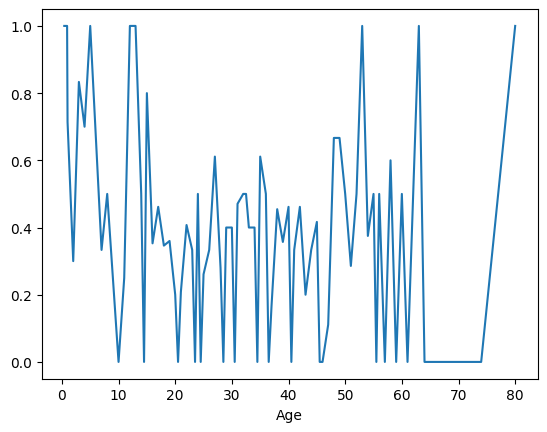

In [127]:
df.groupby(['Age'])['Survived'].mean().plot()

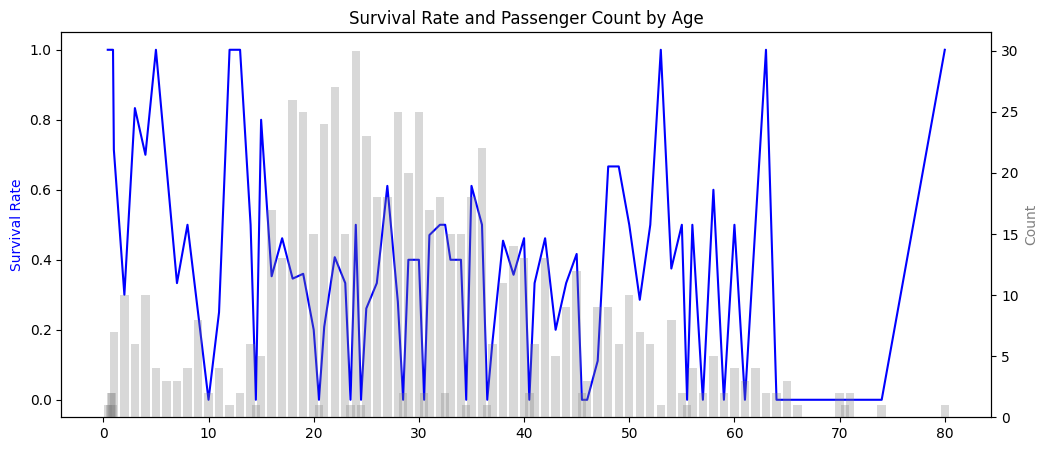

In [128]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df.groupby('Age')['Survived'].mean(), color='blue', label='Survival Rate')
ax1.set_ylabel('Survival Rate', color='blue')

ax2 = ax1.twinx()
ax2.bar(df['Age'].value_counts().sort_index().index, 
        df['Age'].value_counts().sort_index().values, 
        alpha=0.3, color='gray', label='Count')
ax2.set_ylabel('Count', color='gray')

plt.title('Survival Rate and Passenger Count by Age')
plt.show()

Even though the survival rate cannot be assumed from this as data seems to be noisy, we can still see a bias towards younger passengers with consistently higher peaks as compared to adults 

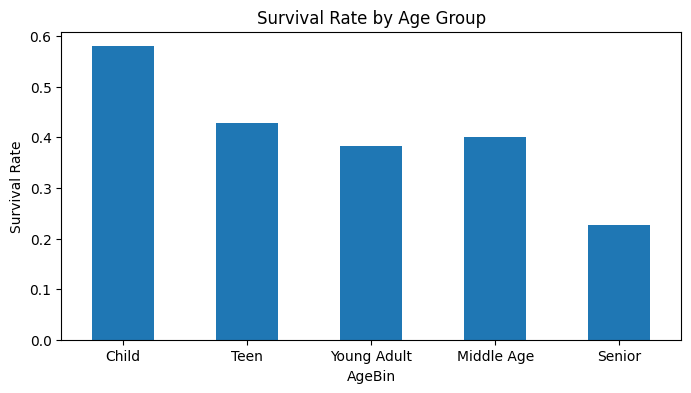

In [129]:
df['AgeBin'] = pd.cut(df['Age'], bins=[0,12,18,35,60,80], 
                       labels=['Child','Teen','Young Adult','Middle Age','Senior'])

df.groupby('AgeBin')['Survived'].mean().plot(kind='bar', figsize=(8,4))
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

Shows a clear bias towards children.

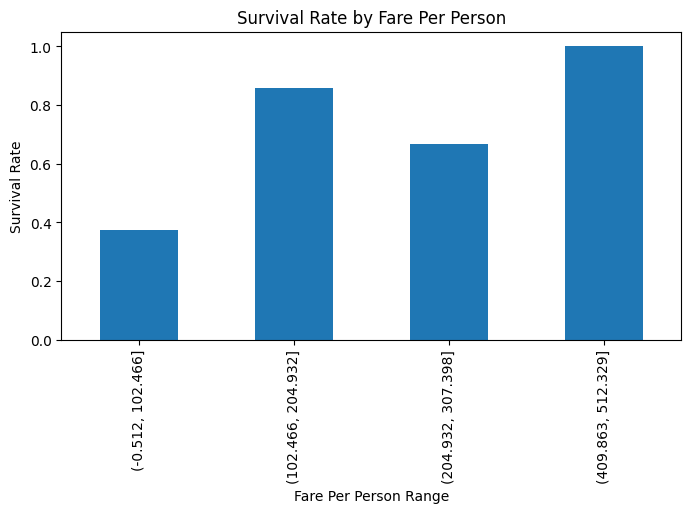

In [130]:
df.groupby(pd.cut(df['FarePP'], bins=5), observed=True)['Survived'].mean().plot(kind='bar', figsize=(8,4))
plt.title('Survival Rate by Fare Per Person')
plt.ylabel('Survival Rate')
plt.xlabel('Fare Per Person Range')
plt.show()

In [131]:
df.groupby(pd.cut(df['FarePP'], bins=5))['Survived'].agg(['mean', 'count'])

,mean,count
FarePP,,
"(-0.512, 102.466]",0.372842,869
"(102.466, 204.932]",0.857143,14
"(204.932, 307.398]",0.666667,6
"(409.863, 512.329]",1.000000,2


Distribution of passengers on the basis of fare division doesnt seem like a linear relation, as 869/891 passengers are in the lowest category, we need  a better way to categorise passengers based on the FarePP metric

In [132]:
df.groupby(pd.cut(df['FarePP'], bins=50))['Survived'].agg(['mean', 'count'])

,mean,count
FarePP,,
"(-0.512, 10.247]",0.270955,513
"(10.247, 20.493]",0.434211,152
"(20.493, 30.74]",0.551020,98
"(30.74, 40.986]",0.512821,39
"(40.986, 51.233]",0.625000,24
"(51.233, 61.48]",0.650000,20
"(61.48, 71.726]",0.750000,4
"(71.726, 81.973]",0.642857,14
"(81.973, 92.219]",1.000000,4


In [133]:
df.groupby(pd.qcut(df['FarePP'], q=5))['Survived'].agg(['mean', 'count'])

,mean,count
FarePP,,
"(-0.001, 7.142]",0.284916,179
"(7.142, 7.896]",0.255208,192
"(7.896, 10.5]",0.289017,173
"(10.5, 26.55]",0.466292,178
"(26.55, 512.329]",0.644970,169


Tells a much better story, we can distribute passengers in the following manner
Lower- Below 10.5 | 
Middle- Between 10.5 and 26.55 | 
Upper- Above 26.55

In [134]:
df['FareClass'] = pd.cut(df['FarePP'], 
                          bins=[-1, 10.5, 26.55, 512],
                          labels=['Lower', 'Middle', 'Upper'])

df.groupby('FareClass')['Survived'].agg(['mean', 'count'])

,mean,count
FareClass,,
Lower,0.275735,544
Middle,0.466292,178
Upper,0.640719,167


Confirms the assumption that FareClass is a good metric to estimate a passengers survivability index.

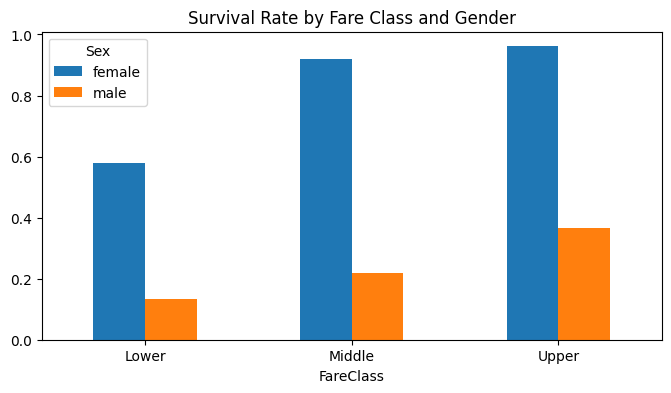

In [135]:
df.groupby(['FareClass', 'Sex'])['Survived'].mean().unstack().plot(kind='bar', figsize=(8,4))
plt.title('Survival Rate by Fare Class and Gender')
plt.xticks(rotation=0)
plt.show()

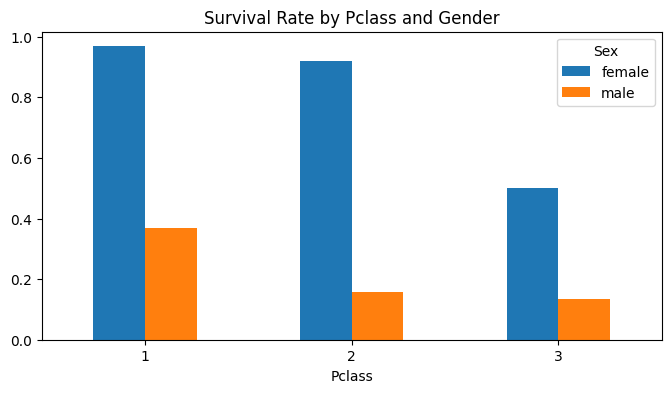

In [136]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().plot(kind='bar', figsize=(8,4))
plt.title('Survival Rate by Pclass and Gender')
plt.xticks(rotation=0)
plt.show()

In [137]:
pd.crosstab(df['Pclass'], df['FareClass'])

FareClass,Lower,Middle,Upper
Pclass,,,
1,7,50,157
2,72,109,3
3,465,19,7


In [138]:
df.groupby('FareClass')['Survived'].agg(['mean', 'count'])

,mean,count
FareClass,,
Lower,0.275735,544
Middle,0.466292,178
Upper,0.640719,167


In [139]:
df.groupby('Pclass')['Survived'].agg(['mean', 'count'])

,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


In [140]:
df.groupby(['FareClass', 'Pclass'])['Survived'].agg(['mean', 'count'])

mean  count
FareClass Pclass                 
Lower     1       0.142857      7
          2       0.541667     72
          3       0.236559    465
Middle    1       0.640000     50
          2       0.431193    109
          3       0.210526     19
Upper     1       0.643312    157
          2       0.333333      3
          3       0.714286      7

The outliers with high FarePP but lower Pclass or vice versa are outliers which might have been caused by family distribution

Using both FareClass and Pclass together might be redundant since FareClass is derived from FarePP, which is closely related to Pclass. It may not provide much additional insight beyond what Pclass already indicates.

Even though FareClass proivded a broader and clearer gap using a more objective attribute such as Pclass seems like a better approach as FareClass relies on averages not skewing the data

Currently the best parameters are IsWoman, Age, Pclass

In [141]:
df['PclassScore'] = (4 - df['Pclass']) / 3

In [142]:
df['AgeScore'] = (df['AgeBin'] == 'Child').astype(int) * 0.5

In [143]:
df['SurvIndex']=((df['IsWoman']*0.5) + df['PclassScore']*0.3 + df['AgeScore']*0.2)

In [144]:
df.groupby(pd.qcut(df['SurvIndex'], q=10, duplicates='drop'))['Survived'].agg(['mean', 'count'])

,mean,count
SurvIndex,,
"(0.09999999999999998, 0.19999999999999996]",0.109264,421
"(0.19999999999999996, 0.2]",0.360000,25
"(0.2, 0.3]",0.398438,128
"(0.3, 0.6]",0.516129,124
"(0.6, 0.7]",0.802198,91
"(0.7, 0.8]",0.980198,101
"(0.8, 0.9]",0.000000,1


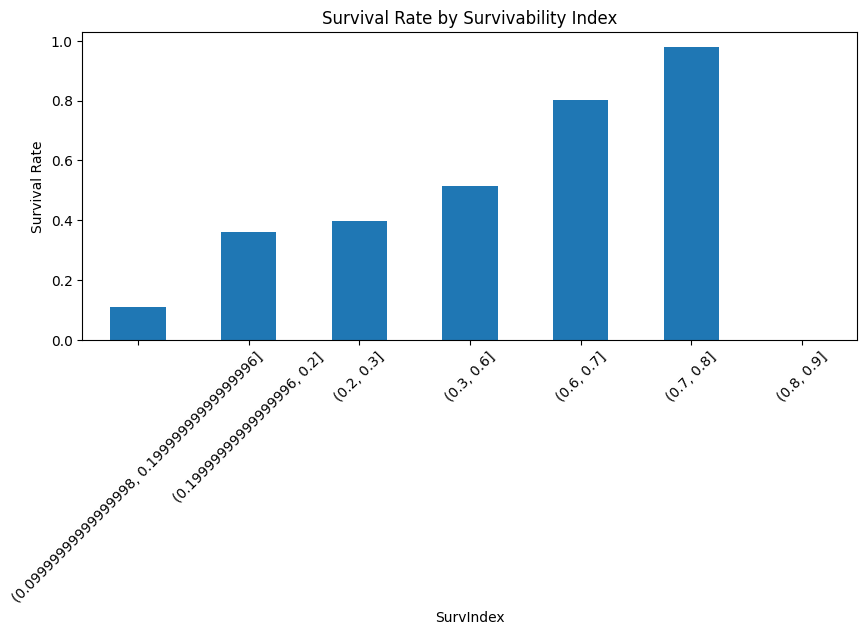

In [145]:
df.groupby(pd.qcut(df['SurvIndex'], q=10, duplicates='drop'))['Survived'].mean().plot(
    kind='bar', figsize=(10,4))
plt.title('Survival Rate by Survivability Index')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.show()

In [146]:
def predict_from_index(index):
    return 1 if index > 0.5 else 0 

df['Predicted'] = df['SurvIndex'].apply(predict_from_index)

In [ ]:
#Accuracy
acc = accuracy_score(df['Survived'], df['Predicted'])
print("Accuracy:", acc)

#Confusion Matrix
cm = confusion_matrix(df['Survived'], df['Predicted'])
print("Confusion Matrix:\n", cm)

Accuracy: 0.7867564534231201
Confusion Matrix:
 [[468  81]
 [109 233]]


[[TN  FP]
 [FN  TP]]

The rule-based SurvIndex achieves (approx)78.7% accuracy. 
However, the model shows higher false negatives, indicating that some surviving passengers are not captured due to the simplified feature design

In [153]:
for t in [0.4, 0.5, 0.6]:
    preds = (df['SurvIndex'] > t).astype(int)
    acc = accuracy_score(df['Survived'], preds)
    print(f"Threshold {t} → Accuracy: {acc:.20f}")

Threshold 0.4 → Accuracy: 0.78675645342312006125
Threshold 0.5 → Accuracy: 0.78675645342312006125
Threshold 0.6 → Accuracy: 0.78563411896745227736


Threshold tuning showed that 0.4 and 0.5 yield identical accuracy, indicating that the SurvIndex produces clustered values rather than a continuous distribution.

Thus lets just pick 0.5 as the threshold with accuracy ~78.6%

Trying to compare the results with a simple logistic regression mode.


In [148]:
features= [ 'IsWoman', 'PclassScore', 'AgeScore','FarePP', 'FamilySize']
df_model=df[features + ['Survived']].dropna()

X=df_model[features]
y=df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7932960893854749


In [149]:
features= [ 'IsWoman', 'PclassScore', 'AgeScore']
df_model=df[features + ['Survived']].dropna()

X=df_model[features]
y=df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7877094972067039


The initial assumption that FarePP and FamilySize were a helpful metric for the Survivability Index was not supported by the 0.6% increase in accuracy of the 5-feature model as compared to the 3-features.
This demonstrates Occam's Razor(when presented with competing hypotheses, one should prefer the one requiring the fewest assumptions) in ML, when two models give similar results pick the simpler one.

The 3-feature model is less likely to be overfitted on unseen data and easier to interpret and explain.
Thus, the core survival predictors - Gender, Passenger Class, and Age are sufficient to achieve 79% accuracy, consistent with the historical 'women and children first' evacuation policy.

Accuracy of model based on features[ 'IsWoman', 'PclassScore', 'AgeScore'] = 78.6%                                                  
Accuracy of model based on features[ 'IsWoman', 'PclassScore', 'AgeScore'] with Logistic Regression = 78.8%                                             
Accuracy of model based on features[ 'IsWoman', 'PclassScore', 'AgeScore','FarePP', 'FamilySize'] with Logistic Regression = 79.3%

Additional features do not justify their complexity, while Logistic Regression offers a small but consistent improvement without sacrificing interpretability.